# OmniDocBench v1.5 Evaluation for PaddleOCR-VL Parser

This notebook evaluates your parser output against **OmniDocBench v1.5** annotations, focusing on **English, digital/native PDF pages**.

It is designed for this workflow:

1. Prepare a small English subset from the **pinned OmniDocBench v1.5 Hugging Face revision**.
2. Export sample PDFs to `examples/pdfs/`, plus images, annotations, and `manifest.csv` under `evaluation_data_omni/`.
3. Run your parser on those PDFs (e.g. via `smoke_tests/run_one.py`).
4. Point this notebook at parser outputs (default: `smoke_tests/`).
5. Compute layout, text, table, formula, reading-order, Markdown/JSON, and runtime metrics.

The notebook is intentionally practical: it uses your existing `document.json` schema and avoids requiring the full official OmniDocBench environment unless you explicitly want to run the official evaluator.


## 1. Metric scope

OmniDocBench v1.5's official evaluation supports:

- **End-to-end evaluation**: text paragraphs, display formulas, tables, and reading order.
- **Layout detection**: COCODet metrics such as mAP / mAR.
- **Text OCR**: normalized edit distance, BLEU, METEOR.
- **Formula recognition**: normalized edit distance and CDM / CDM export.
- **Table recognition**: TEDS and normalized edit distance.

This notebook includes lightweight implementations or fallbacks for those metric families:

| Area | Notebook metric |
|---|---|
| Layout | IoU matching, precision/recall/F1 at 0.5 and 0.75, mean IoU, optional pycocotools export |
| Text | normalized edit distance, optional BLEU/METEOR if `nltk` is installed |
| Tables | table detection F1, HTML/text normalized edit distance, optional TEDS-like hook |
| Formulas | formula detection F1, LaTeX normalized edit distance, CDM pair export |
| Reading order | sequence normalized edit distance / pairwise order accuracy |
| Official evaluator | optional export folders/configs compatible with OmniDocBench v1.5-style evaluation |

This notebook pins the Hugging Face dataset to the known v1.5-era revision by default, because the public `main` branch has since moved to v1.6.


## 2. Configuration

Edit this cell first. Sample PDFs are written to `examples/pdfs/`; parser runs typically go through `smoke_tests/` outputs.

In [21]:
from pathlib import Path
import json, re, os, csv, shutil, random, math, sys, subprocess, warnings, unicodedata
from collections import defaultdict, Counter
from typing import Any, Dict, List, Optional, Tuple

# ── Project paths ─────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()  # Change if needed

# OmniBench prep splits downloads:
# - Sample PDF files → OMNI_SAMPLE_PDF_DIR (examples/pdfs; usually already in the repo).
# - Annotations, page images, manifest, HF cache JSON → EVAL_DATA_DIR / omnidocbench_v15_english / … only.
EVAL_DATA_DIR = PROJECT_ROOT / "evaluation_data_omni"
OMNI_OUTPUT_DIR = EVAL_DATA_DIR / "omnidocbench_v15_english"
OMNI_SAMPLE_PDF_DIR = PROJECT_ROOT / "examples" / "pdfs"
OMNI_IMAGES_DIR = OMNI_OUTPUT_DIR / "images"
OMNI_ANNOTATIONS_DIR = OMNI_OUTPUT_DIR / "annotations"
OMNI_MANIFEST_CSV = OMNI_OUTPUT_DIR / "manifest.csv"
MASTER_MANIFEST_CSV = EVAL_DATA_DIR / "manifest.csv"

# Parser outputs: same convention as DocLayNet — e.g. smoke_tests/<pdf_stem>/<backend_device>/document.json.
# Default searches the whole tree for document.json; override to a single run folder if needed.
PREDICTION_RUN_DIR = PROJECT_ROOT / "smoke_tests"

# Optional parser markdown/timing paths. The notebook will discover these when possible.
PRED_MARKDOWN_GLOB = "**/*.md"
PRED_TIMING_GLOB = "**/timing.json"

# Results
OUTPUT_DIR = PROJECT_ROOT / "evaluation_results_omni" / "omnidocbench_v15_english"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── OmniDocBench v1.5 download / subset config ───────────────────────────────
OMNI_REPO_ID = "opendatalab/OmniDocBench"
OMNI_VERSION = "v1.5"

# IMPORTANT:
# Hugging Face `main` now points to newer OmniDocBench releases.
# This commit is the v1.5-era dataset revision visible in the HF history.
# Keep this pinned for strict v1.5 evaluation.
OMNI_REVISION = "f1ad5a6a46b5695ff5b43091ef4fe0c61f8170f2"

# `OmniDocBench.json` list length depends on HF snapshot — not a universal constant.
# Pinned OMNI_REVISION `f1ad5a6a…` currently ships **981** records; other v1.5 snapshots may report **1355**.
# ~**1,651** usually means v1.6 / `main` (wrong revision for this notebook).
OMNI_ACCEPTED_JSON_LENGTHS: frozenset = frozenset({981, 1355})
STRICT_OMNI_V15 = True  # If True, len(JSON) must be in OMNI_ACCEPTED_JSON_LENGTHS; else warning only

OMNI_SAMPLE_SIZE = 10
OMNI_RANDOM_SEED = 42
OMNI_LANGUAGE_VALUES = {"en", "english", "text_en", "table_en", "equation_en"}

# Digital-PDF focus:
DIGITAL_ONLY = True
EXCLUDE_DATA_SOURCES_FOR_DIGITAL = {"note"}  # handwritten notes are not the focus
EXCLUDE_FUZZY_SCAN = True

# Prefer native PDF slices from the dataset. If none are found, you can set fallback to True,
# but those PDFs will be image-based PDFs, not native/digital PDFs.
REQUIRE_NATIVE_PDF = False
ALLOW_IMAGE_TO_PDF_FALLBACK = True

# Candidate path patterns searched in the HF dataset repository for native page PDFs.
# The notebook also dynamically searches all repo files for matching stems.
PDF_CANDIDATE_DIRS = [
    "pdfs", "pdf", "PDF", "pdf_pages", "page_pdfs", "images_pdf", "original_pdf", "origin_pdf"
]

# ── Prediction coordinate handling ───────────────────────────────────────────
# Your uploaded sample document.json uses bbox values in PDF points (e.g., page width_pt=612, height_pt=792).
# OmniDocBench polygons are image-pixel coordinates. So default is to scale PDF points → GT image pixels.
PRED_COORD_SPACE = "pdf_points"  # "pdf_points", "image_pixels", or "normalized"
IOU_THRESHOLDS = [0.5, 0.75]

# If only one prediction JSON and one manifest sample exist, allow direct matching.
ALLOW_SINGLE_SAMPLE_DIRECT_MATCH = True

# Label mapping from your parser to OmniDocBench-style labels
PRED_TO_OMNI_LABEL = {
    "paragraph": "text_block",
    "text": "text_block",
    "plain_text": "text_block",
    "heading": "title",
    "title": "title",
    "section_header": "title",
    "page_header": "header",
    "header": "header",
    "page_footer": "footer",
    "footer": "footer",
    "footnote": "page_footnote",
    "page_footnote": "page_footnote",
    "figure": "figure",
    "picture": "figure",
    "image": "figure",
    "caption": "figure_caption",  # best-effort; relation-aware caption typing can be added later
    "table": "table",
    "formula": "equation_isolated",
    "equation": "equation_isolated",
    "list": "list_group",
    "list_item": "list_group",
    "reference": "reference",
    "code": "text_block",
    "section": "title",
}

# Evaluation category mapping, close to OmniDocBench layout config
OMNI_EVAL_LABEL = {
    "title": "title",
    "text_block": "text",
    "reference": "text",
    "list_group": "text",
    "figure": "figure",
    "figure_caption": "figure_caption",
    "figure_footnote": "figure_footnote",
    "table": "table",
    "table_caption": "table_caption",
    "table_footnote": "table_footnote",
    "equation_isolated": "isolate_formula",
    "equation_inline": "inline_formula",
    "equation_caption": "formula_caption",
    "header": "abandon",
    "footer": "abandon",
    "page_number": "abandon",
    "page_footnote": "abandon",
    "abandon": "abandon",
    "code_txt": "figure",
    "code_txt_caption": "figure_caption",
}

# Set to False if you do not want headers/footers/page numbers in layout metrics
INCLUDE_ABANDON_IN_LAYOUT = False

# If True, GT/pred layout matching treats figure_caption, table_caption, etc. as one class "caption",
# and isolate_formula + inline_formula as "formula". Any correct caption/formula box counts; wrong class name does not.
UNIFY_CAPTION_AND_FORMULA_LABELS = True

# OmniBench exports one page per sample. Multi-page document.json rows were all folded into page_num 1 → misleading IoU.
# If True, only the first entry in pages[] is evaluated (warns when len(pages) > 1).
OMNI_SINGLE_PAGE_PARSER_JSON_ONLY = True

print("Configured. Edit paths above if needed.")
print("OmniDocBench version target:", OMNI_VERSION)
print("Pinned HF revision:", OMNI_REVISION)
print("EVAL_DATA_DIR:", EVAL_DATA_DIR)
print("OMNI_SAMPLE_PDF_DIR:", OMNI_SAMPLE_PDF_DIR)
print("PREDICTION_RUN_DIR:", PREDICTION_RUN_DIR)
print("UNIFY_CAPTION_AND_FORMULA_LABELS:", UNIFY_CAPTION_AND_FORMULA_LABELS)
print("OMNI_SINGLE_PAGE_PARSER_JSON_ONLY:", OMNI_SINGLE_PAGE_PARSER_JSON_ONLY)

Configured. Edit paths above if needed.
OmniDocBench version target: v1.5
Pinned HF revision: f1ad5a6a46b5695ff5b43091ef4fe0c61f8170f2
EVAL_DATA_DIR: c:\Users\David Martirosyan\Documents\Projects\Agentic PDF Parser\evaluation_data_omni
OMNI_SAMPLE_PDF_DIR: c:\Users\David Martirosyan\Documents\Projects\Agentic PDF Parser\examples\pdfs
PREDICTION_RUN_DIR: c:\Users\David Martirosyan\Documents\Projects\Agentic PDF Parser\smoke_tests
UNIFY_CAPTION_AND_FORMULA_LABELS: True
OMNI_SINGLE_PAGE_PARSER_JSON_ONLY: True


## 3. Dependencies

In [22]:
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

try:
    from scipy.optimize import linear_sum_assignment
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

try:
    import nltk
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score
    NLTK_AVAILABLE = True
except Exception:
    NLTK_AVAILABLE = False

try:
    from huggingface_hub import hf_hub_download, list_repo_files
    HF_AVAILABLE = True
except Exception:
    HF_AVAILABLE = False

try:
    from bs4 import BeautifulSoup
    BS4_AVAILABLE = True
except Exception:
    BS4_AVAILABLE = False

print("scipy:", SCIPY_AVAILABLE)
print("nltk:", NLTK_AVAILABLE)
print("huggingface_hub:", HF_AVAILABLE)
print("beautifulsoup4:", BS4_AVAILABLE)

scipy: True
nltk: True
huggingface_hub: True
beautifulsoup4: True


## 4. Utility functions

In [23]:
def ensure_dirs():
    # Only evaluation + results trees — not examples/pdfs (sample PDF path is ensured in prepare when writing).
    for p in [EVAL_DATA_DIR, OMNI_OUTPUT_DIR, OMNI_IMAGES_DIR, OMNI_ANNOTATIONS_DIR, OUTPUT_DIR]:
        p.mkdir(parents=True, exist_ok=True)

def safe_stem(path_or_name: str) -> str:
    s = Path(str(path_or_name)).stem
    s = re.sub(r"[^A-Za-z0-9_.-]+", "_", s)
    return s[:180] if len(s) > 180 else s

def normalize_text(s: Any, lower: bool = False) -> str:
    if s is None:
        return ""
    s = str(s)
    s = unicodedata.normalize("NFKC", s)
    s = re.sub(r"\s+", " ", s).strip()
    if lower:
        s = s.lower()
    return s

def levenshtein(a: str, b: str) -> int:
    a, b = str(a), str(b)
    if a == b:
        return 0
    if len(a) < len(b):
        a, b = b, a
    prev = list(range(len(b) + 1))
    for i, ca in enumerate(a, 1):
        curr = [i]
        for j, cb in enumerate(b, 1):
            curr.append(min(prev[j] + 1, curr[j-1] + 1, prev[j-1] + (ca != cb)))
        prev = curr
    return prev[-1]

def norm_edit_distance(pred: Any, gt: Any) -> float:
    pred = normalize_text(pred)
    gt = normalize_text(gt)
    denom = max(len(pred), len(gt), 1)
    return levenshtein(pred, gt) / denom

def similarity_from_edit(pred: Any, gt: Any) -> float:
    return 1.0 - norm_edit_distance(pred, gt)

def poly_to_bbox(poly: Any) -> Optional[List[float]]:
    if poly is None:
        return None
    if isinstance(poly, dict):
        # tolerate {"points": [[x,y], ...]} or similar
        poly = poly.get("points") or poly.get("poly") or poly.get("polygon")
    if not isinstance(poly, (list, tuple)) or len(poly) == 0:
        return None
    if all(isinstance(p, (list, tuple)) and len(p) >= 2 for p in poly):
        xs = [float(p[0]) for p in poly]
        ys = [float(p[1]) for p in poly]
    else:
        if len(poly) < 4:
            return None
        xs = [float(poly[i]) for i in range(0, len(poly), 2)]
        ys = [float(poly[i]) for i in range(1, len(poly), 2)]
    return [min(xs), min(ys), max(xs), max(ys)]

def coco_xywh_to_xyxy(b):
    x, y, w, h = map(float, b)
    return [x, y, x + w, y + h]

def dict_bbox_to_xyxy(b: Dict[str, Any]) -> Optional[List[float]]:
    if not b:
        return None
    if all(k in b for k in ["x0", "y0", "x1", "y1"]):
        return [float(b["x0"]), float(b["y0"]), float(b["x1"]), float(b["y1"])]
    if all(k in b for k in ["x", "y", "w", "h"]):
        return [float(b["x"]), float(b["y"]), float(b["x"]) + float(b["w"]), float(b["y"]) + float(b["h"])]
    return None

def bbox_area(b):
    if b is None:
        return 0.0
    return max(0.0, float(b[2]) - float(b[0])) * max(0.0, float(b[3]) - float(b[1]))

def bbox_iou(a, b):
    if a is None or b is None:
        return 0.0
    x0 = max(a[0], b[0]); y0 = max(a[1], b[1])
    x1 = min(a[2], b[2]); y1 = min(a[3], b[3])
    inter = bbox_area([x0, y0, x1, y1])
    union = bbox_area(a) + bbox_area(b) - inter
    return inter / union if union > 0 else 0.0

def scale_bbox(b, sx: float, sy: float):
    return [float(b[0]) * sx, float(b[1]) * sy, float(b[2]) * sx, float(b[3]) * sy]

def first_existing(*vals):
    for v in vals:
        if v not in (None, "", [], {}):
            return v
    return None

ensure_dirs()

## 5. Dataset preparation: OmniDocBench v1.5 English digital subset

**Where files go:** sample **PDFs** are written under **`examples/pdfs/`**. **Annotations**, **rendered page images**, **manifest** (and the HF repo file list cache) all live under **`evaluation_data_omni/`** only.

```text
examples/pdfs/<sample_id>.pdf
evaluation_data_omni/omnidocbench_v15_english/
  images/*
  annotations/*.json
  manifest.csv
  _hf_repo_files.json
evaluation_data_omni/manifest.csv
```

The notebook downloads `OmniDocBench.json` from the pinned v1.5 Hugging Face revision defined in the config cell.

It filters for English pages using `page_info.page_attribute.language`. For the digital/native-PDF focus, it excludes fuzzy scans and obvious handwritten-note pages when those attributes are present.

If native PDF slices are not found in the pinned dataset revision, the notebook can optionally create image-based PDFs. That fallback is disabled by default because the current focus is **digital/native PDFs**.


In [24]:
def download_omnidocbench_json() -> Path:
    if not HF_AVAILABLE:
        raise ImportError("huggingface_hub is required. Install with: pip install huggingface_hub")
    kwargs = dict(repo_id=OMNI_REPO_ID, repo_type="dataset", filename="OmniDocBench.json")
    if OMNI_REVISION:
        kwargs["revision"] = OMNI_REVISION
    path = hf_hub_download(**kwargs)
    return Path(path)

def load_omnidocbench_json(path: Path) -> List[Dict[str, Any]]:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    if isinstance(data, dict):
        # tolerate {"data": [...]} wrappers
        for key in ["data", "samples", "pages"]:
            if isinstance(data.get(key), list):
                data = data[key]
                break
    assert isinstance(data, list), "Expected OmniDocBench JSON to be a list of page records"
    return data

def assert_omnidocbench_v15(entries: List[Dict[str, Any]]) -> None:
    """Guardrail: reject obvious v1.6/main JSON; accept known v1.5-era snapshot lengths."""
    n = len(entries)
    print(f"Loaded OmniDocBench records: {n}")
    acc = globals().get("OMNI_ACCEPTED_JSON_LENGTHS", frozenset({981, 1355}))
    if n in acc:
        print(f"Version check passed: JSON length {n} matches a known OmniDocBench v1.5-era snapshot (acceptable: {sorted(acc)}).")
        return
    msg = f"OmniDocBench.json has {n} records; this notebook expects one of {sorted(acc)} for a v1.5 pin, or you may have the wrong revision. "
    if n >= 1600:
        msg += "~1,651 is typical of v1.6/main — set OMNI_REVISION to a v1.5 commit or update OMNI_ACCEPTED_JSON_LENGTHS after you verify your file."
    else:
        msg += "If you are sure this file is correct, add " + str(n) + " to OMNI_ACCEPTED_JSON_LENGTHS in the config cell."
    if STRICT_OMNI_V15:
        raise RuntimeError(msg)
    warnings.warn(msg)

def page_attrs(entry):
    return (((entry or {}).get("page_info") or {}).get("page_attribute") or {})

def page_language(entry):
    attrs = page_attrs(entry)
    return first_existing(
        attrs.get("language"),
        attrs.get("lang"),
        attrs.get("text_language"),
    )

def is_english_entry(entry) -> bool:
    lang = page_language(entry)
    if lang is None:
        return False
    lang_norm = str(lang).strip().lower()
    return lang_norm in OMNI_LANGUAGE_VALUES or "english" in lang_norm or lang_norm == "en"

def false_like(v) -> bool:
    if v is False:
        return True
    if v is None:
        return True
    return str(v).strip().lower() in {"false", "0", "no", "none", "null", ""}

def is_digital_focused_entry(entry) -> bool:
    if not DIGITAL_ONLY:
        return True
    attrs = page_attrs(entry)
    ds = str(attrs.get("data_source", "")).strip()
    if ds in EXCLUDE_DATA_SOURCES_FOR_DIGITAL:
        return False
    if EXCLUDE_FUZZY_SCAN and not false_like(attrs.get("fuzzy_scan")):
        return False
    return True

def sample_omni_entries(entries, n=OMNI_SAMPLE_SIZE, seed=OMNI_RANDOM_SEED):
    candidates = [e for e in entries if is_english_entry(e) and is_digital_focused_entry(e)]
    rng = random.Random(seed)
    rng.shuffle(candidates)
    return candidates[:min(n, len(candidates))], candidates

def get_page_info(entry):
    return entry.get("page_info") or {}

def get_image_path(entry):
    info = get_page_info(entry)
    return info.get("image_path") or info.get("image") or info.get("img_path")

def sample_id_from_entry(entry):
    image_path = get_image_path(entry)
    if image_path:
        return safe_stem(image_path)
    info = get_page_info(entry)
    return safe_stem(f"page_{info.get('page_no', len(str(entry)))}_{abs(hash(json.dumps(info, sort_keys=True, default=str))) % 10**8}")

def get_repo_files_cached():
    cache_path = OMNI_OUTPUT_DIR / "_hf_repo_files.json"
    if cache_path.exists():
        return json.loads(cache_path.read_text(encoding="utf-8"))
    if not HF_AVAILABLE:
        return []
    kwargs = dict(repo_id=OMNI_REPO_ID, repo_type="dataset")
    if OMNI_REVISION:
        kwargs["revision"] = OMNI_REVISION
    files = list_repo_files(**kwargs)
    cache_path.write_text(json.dumps(files, ensure_ascii=False, indent=2), encoding="utf-8")
    return files

def hf_download_file(repo_path: str) -> Optional[Path]:
    if not repo_path:
        return None
    if not HF_AVAILABLE:
        return None
    try:
        kwargs = dict(repo_id=OMNI_REPO_ID, repo_type="dataset", filename=repo_path)
        if OMNI_REVISION:
            kwargs["revision"] = OMNI_REVISION
        return Path(hf_hub_download(**kwargs))
    except Exception as e:
        return None

def find_native_pdf_for_entry(entry, repo_files=None) -> Optional[str]:
    info = get_page_info(entry)
    direct_keys = ["pdf_path", "input_pdf", "origin_pdf", "original_pdf", "source_pdf", "pdf"]
    for k in direct_keys:
        if info.get(k):
            return info[k]
    extra = entry.get("extra") or {}
    for k in direct_keys:
        if extra.get(k):
            return extra[k]

    image_path = get_image_path(entry)
    if not image_path:
        return None
    image_path = str(image_path)
    stem = Path(image_path).stem

    # Try direct replacements first
    candidates = []
    for d in PDF_CANDIDATE_DIRS:
        candidates.append(str(Path(d) / (stem + ".pdf")))
    if "/" in image_path:
        candidates.append(str(Path(image_path).with_suffix(".pdf")))
        parts = Path(image_path).parts
        for d in PDF_CANDIDATE_DIRS:
            candidates.append(str(Path(*parts[:-1]) / d / (stem + ".pdf")))

    if repo_files is None:
        repo_files = get_repo_files_cached()

    repo_set = set(repo_files)
    for c in candidates:
        if c in repo_set:
            return c

    # Fuzzy search by stem among repo PDFs
    pdfs = [f for f in repo_files if f.lower().endswith(".pdf")]
    stem_lower = stem.lower()
    exact_stem = [f for f in pdfs if Path(f).stem.lower() == stem_lower]
    if exact_stem:
        return exact_stem[0]
    containing = [f for f in pdfs if stem_lower in Path(f).stem.lower() or Path(f).stem.lower() in stem_lower]
    return containing[0] if containing else None

def export_image_for_entry(entry, sample_id):
    image_path = get_image_path(entry)
    if not image_path:
        return None
    # The JSON stores bare filenames; actual repo files live under images/.
    # Try the path as-is first, then with the images/ prefix.
    candidates = [str(image_path)]
    if not str(image_path).startswith("images/"):
        candidates.append("images/" + str(image_path))
    src = None
    for candidate in candidates:
        src = hf_download_file(candidate)
        if src is not None:
            break
    if src is None:
        return None
    ext = Path(image_path).suffix or ".png"
    dst = OMNI_IMAGES_DIR / f"{sample_id}{ext}"
    if not dst.exists():
        shutil.copyfile(src, dst)
    return dst

def image_to_pdf(image_path: Path, sample_id: str) -> Optional[Path]:
    if not image_path or not Path(image_path).exists():
        return None
    dst = OMNI_SAMPLE_PDF_DIR / f"{sample_id}.pdf"
    img = Image.open(image_path).convert("RGB")
    img.save(dst, "PDF", resolution=200.0)
    return dst

def export_native_pdf_for_entry(entry, sample_id, repo_files=None):
    pdf_repo_path = find_native_pdf_for_entry(entry, repo_files=repo_files)
    if not pdf_repo_path:
        return None, None
    src = hf_download_file(pdf_repo_path)
    if src is None:
        return None, pdf_repo_path
    dst = OMNI_SAMPLE_PDF_DIR / f"{sample_id}.pdf"
    if not dst.exists():
        shutil.copyfile(src, dst)
    return dst, pdf_repo_path

def normalize_omni_annotation(entry, sample_id, input_pdf_path=None, input_image_path=None):
    info = get_page_info(entry)
    width = int(info.get("width") or 0)
    height = int(info.get("height") or 0)
    page_no = int(info.get("page_no") or 0)
    blocks = []
    for i, det in enumerate(entry.get("layout_dets") or []):
        if det.get("ignore") is True:
            continue
        label = det.get("category_type") or det.get("label") or "unknown"
        poly = det.get("poly") or det.get("polygon")
        bbox = poly_to_bbox(poly)
        if bbox is None and det.get("bbox") is not None:
            b = det.get("bbox")
            bbox = coco_xywh_to_xyxy(b) if len(b) == 4 else b
        if bbox is None:
            continue
        blocks.append({
            "gt_id": str(det.get("anno_id", f"{sample_id}_gt_{i}")),
            "label": label,
            "eval_label": OMNI_EVAL_LABEL.get(label, label),
            "bbox": [float(x) for x in bbox],
            "polygon": poly,
            "text": det.get("text"),
            "latex": det.get("latex"),
            "html": det.get("html"),
            "reading_order": det.get("order"),
            "attribute": det.get("attribute") or {},
            "line_with_spans": det.get("line_with_spans") or det.get("line_with_spans:") or [],
        })
    return {
        "sample_id": sample_id,
        "dataset_name": "omnidocbench_v15_english",
        "input_pdf_path": str(input_pdf_path) if input_pdf_path else None,
        "input_image_path": str(input_image_path) if input_image_path else None,
        "page_info": info,
        "pages": [{
            "page_num": page_no + 1,  # Omni uses zero-based page_no in docs
            "omni_page_no": page_no,
            "width": width,
            "height": height,
            "coordinate_space": "image_pixels",
            "blocks": blocks,
        }],
        "extra": entry.get("extra") or {},
    }

def prepare_omnidocbench_subset():
    ensure_dirs()
    OMNI_SAMPLE_PDF_DIR.mkdir(parents=True, exist_ok=True)  # PDFs go here; rest lives under evaluation_data_omni
    print("Downloading/loading OmniDocBench.json...")
    omni_json_path = download_omnidocbench_json()
    print("OmniDocBench.json:", omni_json_path)
    entries = load_omnidocbench_json(omni_json_path)
    assert_omnidocbench_v15(entries)

    sampled, candidates = sample_omni_entries(entries)
    print("English digital-focused candidates:", len(candidates))
    print("Selected samples:", len(sampled))
    if not sampled:
        raise RuntimeError("No English digital-focused samples found. Relax filters in config.")

    repo_files = get_repo_files_cached()
    print("HF repo files indexed:", len(repo_files))

    rows = []
    exported = 0
    skipped_no_pdf = 0
    for entry in tqdm(sampled, desc="Exporting samples"):
        sample_id = sample_id_from_entry(entry)
        info = get_page_info(entry)
        width = int(info.get("width") or 0)
        height = int(info.get("height") or 0)

        image_dst = export_image_for_entry(entry, sample_id)

        pdf_dst, pdf_repo_path = export_native_pdf_for_entry(entry, sample_id, repo_files=repo_files)
        pdf_source = "native_pdf" if pdf_dst else None

        if pdf_dst is None and ALLOW_IMAGE_TO_PDF_FALLBACK and image_dst is not None:
            pdf_dst = image_to_pdf(image_dst, sample_id)
            pdf_source = "image_to_pdf_fallback"

        if REQUIRE_NATIVE_PDF and pdf_source != "native_pdf":
            skipped_no_pdf += 1
            continue

        if pdf_dst is None and image_dst is None:
            skipped_no_pdf += 1
            continue

        ann = normalize_omni_annotation(entry, sample_id, input_pdf_path=pdf_dst, input_image_path=image_dst)
        ann_path = OMNI_ANNOTATIONS_DIR / f"{sample_id}.json"
        ann_path.write_text(json.dumps(ann, ensure_ascii=False, indent=2), encoding="utf-8")

        attrs = page_attrs(entry)
        rows.append({
            "sample_id": sample_id,
            "dataset_name": "omnidocbench_v15_english",
            "input_type": "pdf" if pdf_dst else "image",
            "input_pdf_path": str(pdf_dst) if pdf_dst else "",
            "input_image_path": str(image_dst) if image_dst else "",
            "gt_annotation_path": str(ann_path),
            "page_num": 1,
            "omni_page_no": info.get("page_no"),
            "width": width,
            "height": height,
            "coordinate_space": "image_pixels",
            "language": attrs.get("language"),
            "data_source": attrs.get("data_source"),
            "layout": attrs.get("layout"),
            "fuzzy_scan": attrs.get("fuzzy_scan"),
            "pdf_source": pdf_source or "",
            "hf_pdf_path": pdf_repo_path or "",
            "hf_image_path": get_image_path(entry) or "",
            "notes": "",
        })
        exported += 1

    manifest = pd.DataFrame(rows)
    manifest.to_csv(OMNI_MANIFEST_CSV, index=False)
    manifest.to_csv(MASTER_MANIFEST_CSV, index=False)

    print(f"Exported {exported} samples.")
    if skipped_no_pdf:
        print(f"Skipped {skipped_no_pdf} samples because no native PDF was found and REQUIRE_NATIVE_PDF={REQUIRE_NATIVE_PDF}.")
        print("If needed, set ALLOW_IMAGE_TO_PDF_FALLBACK=True and REQUIRE_NATIVE_PDF=False, but that creates image-based PDFs.")
    print("Manifest:", OMNI_MANIFEST_CSV)
    display(manifest.head())
    return manifest

# IMPORTANT: This cell only DEFINES functions — no downloads happen here.
# Run the **next** cell; it calls `prepare_omnidocbench_subset()` which downloads from Hugging Face.
# Empty folders under evaluation_data_omni are usually created earlier by `ensure_dirs()` (§4), not by this cell.

In [26]:
# Downloads OmniDocBench.json + exports PDFs/images (run AFTER the §5 definitions cell above).
# Set RERUN_OMNI_DATA_PREP = False to load manifest.csv only, without re-fetching from Hugging Face.
RERUN_OMNI_DATA_PREP = True

if RERUN_OMNI_DATA_PREP or not OMNI_MANIFEST_CSV.exists():
    manifest_df = prepare_omnidocbench_subset()
else:
    manifest_df = pd.read_csv(OMNI_MANIFEST_CSV)
    print("Loaded existing manifest:", OMNI_MANIFEST_CSV, "rows:", len(manifest_df))
    display(manifest_df.head())


Downloading/loading OmniDocBench.json...
OmniDocBench.json: C:\Users\David Martirosyan\.cache\huggingface\hub\datasets--opendatalab--OmniDocBench\snapshots\f1ad5a6a46b5695ff5b43091ef4fe0c61f8170f2\OmniDocBench.json
Loaded OmniDocBench records: 981
Version check passed: JSON length 981 matches a known OmniDocBench v1.5-era snapshot (acceptable: [981, 1355]).
English digital-focused candidates: 289
Selected samples: 10
HF repo files indexed: 1361


Exporting samples:   0%|          | 0/10 [00:00<?, ?it/s]

  HF download FAILED for 'yanbaor2_ey-icl-harnessing-the-power-of-data.pdf_13.jpg': RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-69f087c3-6cc315f719ae5d9e5c23c437;d3e8dccc-36d2-40af-9050-0410c9e72427)

Entry Not Found for url: https://huggingface.co/datasets/opendatalab/OmniDocBench/resolve/f1ad5a6a46b5695ff5b43091ef4fe0c61f8170f2/yanbaor2_ey-icl-harnessing-the-power-of-data.pdf_13.jpg.


images/yanbaor2_ey-icl-harnessing-the-po(…):   0%|          | 0.00/195k [00:00<?, ?B/s]

  HF download FAILED for 'docstructbench_llm-raw-scihub-o.O-j.msec.2005.03.002.pdf_7.jpg': RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-69f087c6-709ecfbd035b54dc7deabf16;d68e99db-04e0-47cc-8f58-6185a3ecc35e)

Entry Not Found for url: https://huggingface.co/datasets/opendatalab/OmniDocBench/resolve/f1ad5a6a46b5695ff5b43091ef4fe0c61f8170f2/docstructbench_llm-raw-scihub-o.O-j.msec.2005.03.002.pdf_7.jpg.


...

images/newspaper_baa51a22898f0d534a6c404(…):   0%|          | 0.00/703k [00:00<?, ?B/s]

  HF download FAILED for 'docstructbench_llm-raw-scihub-o.O-s0167-8655%2801%2900019-8.pdf_10.jpg': RemoteEntryNotFoundError: 404 Client Error. (Request ID: Root=1-69f087cf-61f033fb165f55da3e13ae65;3dbb6bf1-1996-44dd-bbe5-32d5ce448e80)

Entry Not Found for url: https://huggingface.co/datasets/opendatalab/OmniDocBench/resolve/f1ad5a6a46b5695ff5b43091ef4fe0c61f8170f2/docstructbench_llm-raw-scihub-o.O-s0167-8655%252801%252900019-8.pdf_10.jpg.


images/docstructbench_llm-raw-scihub-o.O(…):   0%|          | 0.00/620k [00:00<?, ?B/s]

Exported 10 samples.
Manifest: c:\Users\David Martirosyan\Documents\Projects\Agentic PDF Parser\evaluation_data_omni\omnidocbench_v15_english\manifest.csv


,sample_id,dataset_name,input_type,input_pdf_path,input_image_path,gt_annotation_path,page_num,omni_page_no,width,height,coordinate_space,language,data_source,layout,fuzzy_scan,pdf_source,hf_pdf_path,hf_image_path,notes
0,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,omnidocbench_v15_english,pdf,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,1,4714,2662,1500,image_pixels,english,magazine,double_column,None,image_to_pdf_fallback,,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,
1,docstructbench_llm-raw-scihub-o.O-j.msec.2005....,omnidocbench_v15_english,pdf,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,1,7,1653,2206,image_pixels,english,academic_literature,double_column,None,image_to_pdf_fallback,,docstructbench_llm-raw-scihub-o.O-j.msec.2005....,
2,docstructbench_enbook-zlib-o.O-22206811.pdf_5,omnidocbench_v15_english,pdf,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,1,5,1654,2339,image_pixels,english,magazine,single_column,None,image_to_pdf_fallback,,docstructbench_enbook-zlib-o.O-22206811.pdf_5.jpg,
3,scihub_jee_2Ftoaa103.pdf_2,omnidocbench_v15_english,pdf,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,1,2915,1654,2174,image_pixels,english,academic_literature,1andmore_column,None,image_to_pdf_fallback,,scihub_jee%2Ftoaa103.pdf_2.jpg,
4,newspaper_2a6b4fa088699701a6fa9ccecfb5c25d_1,omnidocbench_v15_english,pdf,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,c:\Users\David Martirosyan\Documents\Projects\...,1,1,612,792,image_pixels,english,newspaper,other_layout,None,image_to_pdf_fallback,,newspaper_2a6b4fa088699701a6fa9ccecfb5c25d_1.jpg,


## 6. Run your parser externally

After dataset preparation, run your parser on the PDFs in **`examples/pdfs/`** (see `SMOKE_TEST_BACKEND_DEVICE`, `python smoke_tests/run_one.py ...`).

Default **`PREDICTION_RUN_DIR`** is **`smoke_tests/`** — the notebook collects every **`document.json`** under that tree (same as DocLayNet eval). Override it to a single run directory if you only want one sample.

Typical layout:

```text
smoke_tests/
  <sample_id>/
    paddle_vl_gpu/   # or granite_gpu, etc.
      document.json
      document.md
      timing.json
```

`PRED_MARKDOWN_GLOB` and `PRED_TIMING_GLOB` still apply for discovery anywhere under **`PREDICTION_RUN_DIR`**.

## 7. Load ground truth

In [33]:
def load_manifest(path=OMNI_MANIFEST_CSV) -> pd.DataFrame:
    if not Path(path).exists():
        raise FileNotFoundError(f"Manifest not found: {path}. Run dataset preparation first.")
    df = pd.read_csv(path)
    return df

def load_gt_from_manifest(manifest: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, row in manifest.iterrows():
        ann_path = Path(row["gt_annotation_path"])
        if not ann_path.exists():
            warnings.warn(f"Missing annotation: {ann_path}")
            continue
        ann = json.loads(ann_path.read_text(encoding="utf-8"))
        sample_id = ann.get("sample_id") or row["sample_id"]
        for page in ann.get("pages", []):
            for b in page.get("blocks", []):
                eval_label = b.get("eval_label") or OMNI_EVAL_LABEL.get(b.get("label"), b.get("label"))
                if eval_label == "abandon" and not INCLUDE_ABANDON_IN_LAYOUT:
                    continue
                rows.append({
                    "sample_id": sample_id,
                    "doc_id": sample_id,
                    "page_num": 1,  # Each OmniDocBench sample is one exported page; pred_df always uses page_num=1.
                    "omni_page_no": page.get("omni_page_no"),
                    "gt_id": b.get("gt_id"),
                    "label": b.get("label"),
                    "eval_label": eval_label,
                    "bbox": b.get("bbox"),
                    "polygon": b.get("polygon"),
                    "text": b.get("text"),
                    "latex": b.get("latex"),
                    "html": b.get("html"),
                    "reading_order": b.get("reading_order"),
                    "width": page.get("width"),
                    "height": page.get("height"),
                    "coordinate_space": page.get("coordinate_space", "image_pixels"),
                    "attributes": b.get("attribute") or {},
                })
    return pd.DataFrame(rows)

if OMNI_MANIFEST_CSV.exists():
    manifest_df = load_manifest()
    gt_df = load_gt_from_manifest(manifest_df)
    print("GT blocks:", len(gt_df))
    display(gt_df.head())
    print("GT labels:", gt_df["label"].value_counts().head(20).to_dict() if len(gt_df) else {})
else:
    print("Manifest missing; prepare dataset first.")

GT blocks: 169


,sample_id,doc_id,page_num,omni_page_no,gt_id,label,eval_label,bbox,polygon,text,latex,html,reading_order,width,height,coordinate_space,attributes
0,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,1,4714,10,title,title,"[100.69467163085938, 188.3741455078125, 947.98...","[100.69467163085938, 188.3741455078125, 947.98...",Family Preservation and Assessment System Hill...,NaN,NaN,1.0,2662,1500,image_pixels,"{'text_language': 'text_english', 'text_backgr..."
1,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,1,4714,9,title,title,"[103.13088989257812, 323.10235595703125, 230.7...","[103.13088989257812, 323.10235595703125, 230.7...",Summary,NaN,NaN,2.0,2662,1500,image_pixels,"{'text_language': 'text_english', 'text_backgr..."
2,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,1,4714,0,text_block,text,"[99.24604034423828, 376.3206787109375, 1017.62...","[99.24604034423828, 376.3206787109375, 1017.62...",Hillsborough County's Family Preservation and ...,NaN,NaN,3.0,2662,1500,image_pixels,"{'text_language': 'text_english', 'text_backgr..."
3,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,1,4714,1,title,title,"[101.29625948730403, 709.9380295703177, 271.92...","[101.29625948730403, 709.9380295703177, 271.92...",Interviewees,NaN,NaN,4.0,2662,1500,image_pixels,"{'text_language': 'text_english', 'text_backgr..."
4,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,yanbaor2_ey-icl-harnessing-the-power-of-data.p...,1,4714,12,text_block,text,"[91.04892745149164, 751.8827110281522, 997.845...","[91.04892745149164, 751.8827110281522, 997.845...","- Ramin Kouzehkanani, ClO, Hillsborough County...",NaN,NaN,5.0,2662,1500,image_pixels,"{'text_language': 'text_english', 'text_backgr..."


GT labels: {'text_block': 91, 'title': 35, 'reference': 22, 'figure_caption': 7, 'figure': 7, 'table': 3, 'table_caption': 2, 'table_footnote': 1, 'table_mask': 1}


## 8. Load parser predictions

This adapter is based on your parser's `document.json` schema:

```text
document.source_filename
backend.name / backend.version / backend.device
pages[].dimensions.width_pt / height_pt / width_px / height_px / dpi
pages[].blocks[].id / type / text / reading_order
pages[].blocks[].provenance.bbox.{x0,y0,x1,y1}
pages[].blocks[].table / figure / formula
```

The default conversion assumes predicted bboxes are in **PDF points**, then scales them into OmniDocBench's GT image-pixel coordinate system.

In [34]:
def discover_prediction_jsons(pred_root: Path) -> List[Path]:
    pred_root = Path(pred_root)
    if pred_root.is_file() and pred_root.name.endswith(".json"):
        return [pred_root]
    if not pred_root.exists():
        return []
    return sorted(pred_root.rglob("document.json"))

def table_to_text(table_obj: Any) -> str:
    if not table_obj:
        return ""
    if isinstance(table_obj, dict):
        if table_obj.get("html"):
            return table_obj.get("html") or ""
        cells = table_obj.get("cells") or []
        if cells:
            return " | ".join(normalize_text(c.get("text")) for c in cells if isinstance(c, dict))
        return normalize_text(table_obj)
    return normalize_text(table_obj)

def block_text(block: Dict[str, Any]) -> str:
    if block.get("type") == "formula" and block.get("formula"):
        return block["formula"].get("latex") or block.get("text") or ""
    if block.get("type") == "table" and block.get("table"):
        return table_to_text(block["table"])
    return block.get("text") or ""

def block_latex(block: Dict[str, Any]) -> str:
    if block.get("formula"):
        return block["formula"].get("latex") or ""
    return ""

def block_html(block: Dict[str, Any]) -> str:
    if block.get("table"):
        return block["table"].get("html") or ""
    return ""

def extract_sample_id_from_prediction(doc_json: Dict[str, Any], json_path: Path, manifest: Optional[pd.DataFrame]) -> Optional[str]:
    source = ((doc_json.get("document") or {}).get("source_filename") or "")
    source_stem = safe_stem(source) if source else ""
    path_parts = [safe_stem(p) for p in json_path.parts]
    if manifest is not None and len(manifest):
        # Match by input PDF/image basename
        for _, row in manifest.iterrows():
            sid = str(row["sample_id"])
            input_pdf = safe_stem(row.get("input_pdf_path", ""))
            input_img = safe_stem(row.get("input_image_path", ""))
            candidates = {sid, input_pdf, input_img}
            if source_stem and source_stem in candidates:
                return sid
            if any(sid == pp or sid in pp for pp in path_parts):
                return sid
            if source_stem and any(source_stem in str(row.get(k, "")) for k in ["input_pdf_path", "input_image_path"]):
                return sid
    return source_stem or None

def scale_pred_bbox_to_gt_space(bbox, page_dims, gt_width, gt_height):
    if bbox is None:
        return None
    if PRED_COORD_SPACE == "normalized":
        return scale_bbox(bbox, gt_width, gt_height)
    if PRED_COORD_SPACE == "image_pixels":
        pw = page_dims.get("width_px") or gt_width
        ph = page_dims.get("height_px") or gt_height
        return scale_bbox(bbox, gt_width / float(pw), gt_height / float(ph))
    # default: PDF points
    pw = page_dims.get("width_pt") or page_dims.get("width") or gt_width
    ph = page_dims.get("height_pt") or page_dims.get("height") or gt_height
    return scale_bbox(bbox, gt_width / float(pw), gt_height / float(ph))

def extract_predictions_from_document_json(doc_json: Dict[str, Any], json_path: Path, manifest: Optional[pd.DataFrame]) -> pd.DataFrame:
    sample_id = extract_sample_id_from_prediction(doc_json, json_path, manifest)
    rows = []
    if manifest is not None and len(manifest) == 1 and ALLOW_SINGLE_SAMPLE_DIRECT_MATCH and not sample_id:
        sample_id = str(manifest.iloc[0]["sample_id"])

    # For single-page OmniDocBench PDF slices, match doc-level source to one manifest row.
    manifest_row = None
    if manifest is not None and sample_id in set(manifest["sample_id"].astype(str)):
        manifest_row = manifest[manifest["sample_id"].astype(str) == str(sample_id)].iloc[0]
    elif manifest is not None and len(manifest) == 1 and ALLOW_SINGLE_SAMPLE_DIRECT_MATCH:
        manifest_row = manifest.iloc[0]
        sample_id = str(manifest_row["sample_id"])

    gt_width = int(manifest_row["width"]) if manifest_row is not None and not pd.isna(manifest_row["width"]) else None
    gt_height = int(manifest_row["height"]) if manifest_row is not None and not pd.isna(manifest_row["height"]) else None

    pages_in = doc_json.get("pages") or []
    if globals().get("OMNI_SINGLE_PAGE_PARSER_JSON_ONLY", True):
        if len(pages_in) > 1:
            warnings.warn(
                "document.json has %d pages; OmniBench GT is one page per sample — using only the first page. "
                "Re-run the parser on each single-page OmniBench PDF, or set OMNI_SINGLE_PAGE_PARSER_JSON_ONLY=False." % len(pages_in),
            )
        pages_in = pages_in[:1]

    for p in pages_in:
        page_num = int(p.get("number") or p.get("index", 0) + 1)
        dims = p.get("dimensions") or {}
        # OmniDocBench exported inputs are page-level; parser page 1 maps to sample page.
        if gt_width is None:
            gt_width = int(dims.get("width_px") or dims.get("width_pt") or 0)
        if gt_height is None:
            gt_height = int(dims.get("height_px") or dims.get("height_pt") or 0)

        for b in p.get("blocks", []):
            raw_label = b.get("type") or "unknown"
            omni_label = PRED_TO_OMNI_LABEL.get(raw_label, raw_label)
            eval_label = OMNI_EVAL_LABEL.get(omni_label, omni_label)
            if eval_label == "abandon" and not INCLUDE_ABANDON_IN_LAYOUT:
                continue
            prov = b.get("provenance") or {}
            bbox = dict_bbox_to_xyxy(prov.get("bbox") or {})
            pred_bbox_gt = scale_pred_bbox_to_gt_space(bbox, dims, gt_width, gt_height) if bbox else None
            rows.append({
                "sample_id": sample_id,
                "doc_id": sample_id,
                "page_num": 1,  # local exported PDF is one page; keep GT alignment simple
                "pred_page_num": page_num,
                "element_id": b.get("id"),
                "label": raw_label,
                "omni_label": omni_label,
                "eval_label": eval_label,
                "bbox_raw": bbox,
                "bbox": pred_bbox_gt,
                "polygon": prov.get("polygon"),
                "text": block_text(b),
                "latex": block_latex(b),
                "html": block_html(b),
                "reading_order": b.get("reading_order"),
                "confidence": prov.get("confidence") if prov else None,
                "source_json": str(json_path),
                "source_filename": (doc_json.get("document") or {}).get("source_filename"),
                "page_width_pt": dims.get("width_pt"),
                "page_height_pt": dims.get("height_pt"),
                "page_width_px": dims.get("width_px"),
                "page_height_px": dims.get("height_px"),
            })
    return pd.DataFrame(rows)

def load_all_predictions(pred_root: Path, manifest: Optional[pd.DataFrame]) -> pd.DataFrame:
    jsons = discover_prediction_jsons(pred_root)
    if not jsons:
        print(f"No document.json files found under {pred_root}. Run your parser first or update PREDICTION_RUN_DIR.")
        return pd.DataFrame()
    all_rows = []
    for jp in jsons:
        try:
            doc = json.loads(jp.read_text(encoding="utf-8"))
            df = extract_predictions_from_document_json(doc, jp, manifest)
            all_rows.append(df)
        except Exception as e:
            warnings.warn(f"Failed loading {jp}: {e}")
    if not all_rows:
        return pd.DataFrame()
    return pd.concat(all_rows, ignore_index=True)

if OMNI_MANIFEST_CSV.exists():
    pred_df = load_all_predictions(PREDICTION_RUN_DIR, manifest_df)
    # Keep only predictions whose sample_id appears in the manifest (discard unrelated runs).
    if len(pred_df) and len(manifest_df):
        omni_ids = set(manifest_df["sample_id"].astype(str))
        before = len(pred_df)
        pred_df = pred_df[pred_df["sample_id"].astype(str).isin(omni_ids)].reset_index(drop=True)
        dropped = before - len(pred_df)
        if dropped:
            print(f"Filtered out {dropped} prediction rows from non-OmniDocBench files.")
    print("Prediction blocks:", len(pred_df))
    if len(pred_df):
        display(pred_df.head())
        print("Pred labels:", pred_df["label"].value_counts().head(20).to_dict())
else:
    pred_df = pd.DataFrame()
    print("Prepare dataset and set PREDICTION_RUN_DIR first.")

Filtered out 683 prediction rows from non-OmniDocBench files.
Prediction blocks: 177


C:\Users\David Martirosyan\AppData\Local\Temp\ipykernel_3140\1163567279.py:91: UserWarning: document.json has 74 pages; OmniBench GT is one page per sample — using only the first page. Re-run the parser on each single-page OmniBench PDF, or set OMNI_SINGLE_PAGE_PARSER_JSON_ONLY=False.
  warnings.warn(
C:\Users\David Martirosyan\AppData\Local\Temp\ipykernel_3140\1163567279.py:91: UserWarning: document.json has 74 pages; OmniBench GT is one page per sample — using only the first page. Re-run the parser on each single-page OmniBench PDF, or set OMNI_SINGLE_PAGE_PARSER_JSON_ONLY=False.
  warnings.warn(
C:\Users\David Martirosyan\AppData\Local\Temp\ipykernel_3140\1163567279.py:91: UserWarning: document.json has 15 pages; OmniBench GT is one page per sample — using only the first page. Re-run the parser on each single-page OmniBench PDF, or set OMNI_SINGLE_PAGE_PARSER_JSON_ONLY=False.
  warnings.warn(
C:\Users\David Martirosyan\AppData\Local\Temp\ipykernel_3140\1163567279.py:91: UserWarning:

,sample_id,doc_id,page_num,pred_page_num,element_id,label,omni_label,eval_label,bbox_raw,bbox,...,latex,html,reading_order,confidence,source_json,source_filename,page_width_pt,page_height_pt,page_width_px,page_height_px
0,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,1,1,p0001_b0001,paragraph,text_block,text,"[270.36, 20.88, 285.47999999999996, 29.88]","[751.0, 57.99999999999999, 792.9999999999999, ...",...,,,1,None,c:\Users\David Martirosyan\Documents\Projects\...,docstructbench_enbook-zlib-o.O-19221575.pdf_11...,315.0,531.0,875,1475
1,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,1,1,p0001_b0002,paragraph,text_block,text,"[30.959999999999997, 37.800000000000004, 154.4...","[85.99999999999999, 105.00000000000001, 429.0,...",...,,,2,None,c:\Users\David Martirosyan\Documents\Projects\...,docstructbench_enbook-zlib-o.O-19221575.pdf_11...,315.0,531.0,875,1475
2,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,1,1,p0001_b0003,heading,title,title,"[31.319999999999997, 116.28, 102.24, 126.36]","[86.99999999999999, 323.0, 284.0, 351.0]",...,,,3,None,c:\Users\David Martirosyan\Documents\Projects\...,docstructbench_enbook-zlib-o.O-19221575.pdf_11...,315.0,531.0,875,1475
3,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,1,1,p0001_b0004,paragraph,text_block,text,"[31.319999999999997, 128.51999999999998, 153.7...","[86.99999999999999, 356.99999999999994, 427.0,...",...,,,4,None,c:\Users\David Martirosyan\Documents\Projects\...,docstructbench_enbook-zlib-o.O-19221575.pdf_11...,315.0,531.0,875,1475
4,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,1,1,p0001_b0005,paragraph,text_block,text,"[31.68, 146.51999999999998, 153.72, 165.600000...","[88.0, 406.99999999999994, 427.0, 460.00000000...",...,,,5,None,c:\Users\David Martirosyan\Documents\Projects\...,docstructbench_enbook-zlib-o.O-19221575.pdf_11...,315.0,531.0,875,1475


Pred labels: {'paragraph': 124, 'heading': 39, 'figure': 7, 'caption': 4, 'table': 3}


## 9. Coordinate diagnostics

In [35]:
def coordinate_diagnostics(gt_df, pred_df):
    print("GT rows:", len(gt_df), "Pred rows:", len(pred_df))
    if len(gt_df):
        print("GT coordinate range:")
        boxes = np.array(gt_df["bbox"].dropna().tolist(), dtype=float)
        print("x:", boxes[:, [0,2]].min(), boxes[:, [0,2]].max(), "y:", boxes[:, [1,3]].min(), boxes[:, [1,3]].max())
        print("GT page sizes:", gt_df[["sample_id","width","height"]].drop_duplicates().head().to_dict("records"))
    if len(pred_df):
        print("Prediction coordinate range after scaling:")
        boxes = np.array(pred_df["bbox"].dropna().tolist(), dtype=float)
        print("x:", boxes[:, [0,2]].min(), boxes[:, [0,2]].max(), "y:", boxes[:, [1,3]].min(), boxes[:, [1,3]].max())
        cols = ["sample_id","page_width_pt","page_height_pt","page_width_px","page_height_px"]
        print("Prediction page sizes:", pred_df[cols].drop_duplicates().head().to_dict("records"))
    if len(gt_df) and len(pred_df):
        common = sorted(set(gt_df["sample_id"].astype(str)) & set(pred_df["sample_id"].astype(str)))
        print("Common sample_ids:", len(common), common[:10])
        if not common:
            print("No sample_id overlap. Check parser output paths/source_filename and manifest matching.")

if "gt_df" in globals() and "pred_df" in globals():
    coordinate_diagnostics(gt_df, pred_df)

GT rows: 169 Pred rows: 177
GT coordinate range:
x: 41.299155062210204 1547.8919971897556 y: 57.824801835428616 2054.5316769428773
GT page sizes: [{'sample_id': 'yanbaor2_ey-icl-harnessing-the-power-of-data.pdf_13', 'width': 2662, 'height': 1500}, {'sample_id': 'docstructbench_llm-raw-scihub-o.O-j.msec.2005.03.002.pdf_7', 'width': 1653, 'height': 2206}, {'sample_id': 'docstructbench_enbook-zlib-o.O-22206811.pdf_5', 'width': 1654, 'height': 2339}, {'sample_id': 'scihub_jee_2Ftoaa103.pdf_2', 'width': 1654, 'height': 2174}, {'sample_id': 'newspaper_2a6b4fa088699701a6fa9ccecfb5c25d_1', 'width': 612, 'height': 792}]
Prediction coordinate range after scaling:
x: 10.0 1613.0000000000002 y: 33.12 2081.0
Prediction page sizes: [{'sample_id': 'docstructbench_enbook-zlib-o.O-19221575.pdf_1173', 'page_width_pt': 315.0, 'page_height_pt': 531.0, 'page_width_px': 875, 'page_height_px': 1475}, {'sample_id': 'docstructbench_enbook-zlib-o.O-22206811.pdf_5', 'page_width_pt': 595.4400024414062, 'page_heig

## 10. Matching and layout evaluation

**What is already aligned (no extra fix needed):** `paragraph` / `list` / `list_item` / `reference` blocks all map to the same **`eval_label` = `text`** as OmniDocBench `text_block` / `list_group` / `reference`, so normal body text and lists match on class.

**Notebook-side fixes:** `UNIFY_CAPTION_AND_FORMULA_LABELS` merges caption/formula subtypes; `OMNI_SINGLE_PAGE_PARSER_JSON_ONLY` uses only **`pages[0]`** so multi-page PDF outputs do not collapse into one bogus page. **`code`** / **`section`** map to Omni categories via `PRED_TO_OMNI_LABEL`.

**Parser-side only:** Wrong region types (e.g. body labeled `page_header`) or **`INCLUDE_ABANDON_IN_LAYOUT`** policy — fix classification or toggle the flag, not the matcher.

Optional: set `class_aware=False` in `evaluate_layout(...)` in the code cell below to match boxes **ignoring** category (sensitive to false positives; rarely needed).


In [36]:
def match_page(gt_page: pd.DataFrame, pred_page: pd.DataFrame, iou_threshold=0.5, class_aware=True):
    gt_page = gt_page.reset_index(drop=True)
    pred_page = pred_page.reset_index(drop=True)
    if len(gt_page) == 0 or len(pred_page) == 0:
        return [], list(range(len(pred_page))), list(range(len(gt_page)))

    pairs = []
    if class_aware:
        labels = sorted(set(gt_page["eval_label"].astype(str)) | set(pred_page["eval_label"].astype(str)))
        for lab in labels:
            gt_idx = list(gt_page.index[gt_page["eval_label"].astype(str) == lab])
            pr_idx = list(pred_page.index[pred_page["eval_label"].astype(str) == lab])
            pairs.extend(_match_indices(gt_page, pred_page, gt_idx, pr_idx, iou_threshold))
    else:
        pairs = _match_indices(gt_page, pred_page, list(gt_page.index), list(pred_page.index), iou_threshold)

    matched_gt = {g for g, p, iou in pairs}
    matched_pr = {p for g, p, iou in pairs}
    fp = [i for i in range(len(pred_page)) if i not in matched_pr]
    fn = [i for i in range(len(gt_page)) if i not in matched_gt]
    return pairs, fp, fn

def _match_indices(gt_page, pred_page, gt_idx, pr_idx, iou_threshold):
    if not gt_idx or not pr_idx:
        return []
    ious = np.zeros((len(gt_idx), len(pr_idx)), dtype=float)
    for i, gi in enumerate(gt_idx):
        for j, pj in enumerate(pr_idx):
            ious[i, j] = bbox_iou(gt_page.loc[gi, "bbox"], pred_page.loc[pj, "bbox"])

    pairs = []
    if SCIPY_AVAILABLE:
        # maximize IoU -> minimize -IoU
        rr, cc = linear_sum_assignment(-ious)
        for r, c in zip(rr, cc):
            if ious[r, c] >= iou_threshold:
                pairs.append((gt_idx[r], pr_idx[c], float(ious[r, c])))
    else:
        candidates = []
        for i, gi in enumerate(gt_idx):
            for j, pj in enumerate(pr_idx):
                candidates.append((float(ious[i, j]), gi, pj))
        candidates.sort(reverse=True)
        used_g, used_p = set(), set()
        for iou, gi, pj in candidates:
            if iou < iou_threshold:
                break
            if gi not in used_g and pj not in used_p:
                used_g.add(gi); used_p.add(pj)
                pairs.append((gi, pj, iou))
    return pairs

def evaluate_layout(gt_df, pred_df, thresholds=IOU_THRESHOLDS, class_aware=True):
    results = []
    all_matches = []
    all_fp = []
    all_fn = []

    group_cols = ["sample_id", "page_num"]
    for thr in thresholds:
        tp = fp = fn = 0
        per_label = defaultdict(lambda: {"tp":0, "fp":0, "fn":0, "ious":[]})
        for key, gt_page in gt_df.groupby(group_cols):
            sample_id, page_num = key
            pred_page = pred_df[(pred_df["sample_id"].astype(str) == str(sample_id)) & (pred_df["page_num"].astype(int) == int(page_num))]
            pairs, fp_idx, fn_idx = match_page(gt_page, pred_page, iou_threshold=thr, class_aware=class_aware)

            tp += len(pairs); fp += len(fp_idx); fn += len(fn_idx)

            gt_page_reset = gt_page.reset_index(drop=True)
            pred_page_reset = pred_page.reset_index(drop=True)

            for gi, pi, iou in pairs:
                glab = gt_page_reset.loc[gi, "eval_label"]
                plab = pred_page_reset.loc[pi, "eval_label"]
                per_label[glab]["tp"] += 1
                per_label[glab]["ious"].append(iou)
                if thr == thresholds[0]:
                    all_matches.append({
                        "sample_id": sample_id,
                        "page_num": page_num,
                        "gt_id": gt_page_reset.loc[gi, "gt_id"],
                        "pred_id": pred_page_reset.loc[pi, "element_id"],
                        "gt_label": gt_page_reset.loc[gi, "label"],
                        "pred_label": pred_page_reset.loc[pi, "label"],
                        "gt_eval_label": glab,
                        "pred_eval_label": plab,
                        "iou": iou,
                        "gt_text": gt_page_reset.loc[gi, "text"],
                        "pred_text": pred_page_reset.loc[pi, "text"],
                        "gt_latex": gt_page_reset.loc[gi, "latex"],
                        "pred_latex": pred_page_reset.loc[pi, "latex"],
                        "gt_html": gt_page_reset.loc[gi, "html"],
                        "pred_html": pred_page_reset.loc[pi, "html"],
                        "gt_order": gt_page_reset.loc[gi, "reading_order"],
                        "pred_order": pred_page_reset.loc[pi, "reading_order"],
                    })
            for pi in fp_idx:
                plab = pred_page_reset.loc[pi, "eval_label"] if len(pred_page_reset) else "unknown"
                per_label[plab]["fp"] += 1
                if thr == thresholds[0] and len(pred_page_reset):
                    all_fp.append(pred_page_reset.loc[pi].to_dict())
            for gi in fn_idx:
                glab = gt_page_reset.loc[gi, "eval_label"] if len(gt_page_reset) else "unknown"
                per_label[glab]["fn"] += 1
                if thr == thresholds[0] and len(gt_page_reset):
                    all_fn.append(gt_page_reset.loc[gi].to_dict())

        precision = tp / (tp + fp) if tp + fp else 0
        recall = tp / (tp + fn) if tp + fn else 0
        f1 = 2*precision*recall/(precision+recall) if precision+recall else 0
        mean_iou = np.mean([m["iou"] for m in all_matches]) if all_matches and thr == thresholds[0] else np.nan
        results.append({"iou_threshold": thr, "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1, "mean_iou_at_first_threshold": mean_iou})

        if thr == thresholds[0]:
            per_class_rows = []
            for lab, d in per_label.items():
                p = d["tp"] / (d["tp"] + d["fp"]) if d["tp"] + d["fp"] else 0
                r = d["tp"] / (d["tp"] + d["fn"]) if d["tp"] + d["fn"] else 0
                f = 2*p*r/(p+r) if p+r else 0
                per_class_rows.append({
                    "label": lab, "tp": d["tp"], "fp": d["fp"], "fn": d["fn"],
                    "precision": p, "recall": r, "f1": f,
                    "mean_iou": float(np.mean(d["ious"])) if d["ious"] else np.nan,
                })
            per_class_df = pd.DataFrame(per_class_rows).sort_values("f1", ascending=True) if per_class_rows else pd.DataFrame()

    summary_df = pd.DataFrame(results)
    matches_df = pd.DataFrame(all_matches)
    fp_df = pd.DataFrame(all_fp)
    fn_df = pd.DataFrame(all_fn)
    return summary_df, per_class_df, matches_df, fp_df, fn_df

_CAPTION_UNIFY = frozenset({"figure_caption", "table_caption", "formula_caption", "code_txt_caption", "caption"})
_FORMULA_UNIFY = frozenset({"isolate_formula", "inline_formula", "formula"})

def eval_label_unified_caption_formula(lab):
    """Collapse OmniBench caption/formula subdivisions for fair matching vs parser output."""
    if lab is None or (isinstance(lab, float) and pd.isna(lab)):
        return lab
    s = str(lab)
    if s in _CAPTION_UNIFY:
        return "caption"
    if s in _FORMULA_UNIFY:
        return "formula"
    return s

def apply_unified_caption_formula_labels(df: pd.DataFrame) -> pd.DataFrame:
    if df is None or len(df) == 0 or not UNIFY_CAPTION_AND_FORMULA_LABELS:
        return df
    out = df.copy()
    out["eval_label"] = out["eval_label"].map(eval_label_unified_caption_formula)
    return out

if "gt_df" in globals() and "pred_df" in globals() and len(pred_df):
    _gt_l = apply_unified_caption_formula_labels(gt_df)
    _pred_l = apply_unified_caption_formula_labels(pred_df)
    layout_summary_df, per_class_layout_df, matches_df, false_positives_df, false_negatives_df = evaluate_layout(_gt_l, _pred_l)
    print("Layout summary")
    display(layout_summary_df)
    print("Per-class layout")
    display(per_class_layout_df)
else:
    layout_summary_df = per_class_layout_df = matches_df = false_positives_df = false_negatives_df = pd.DataFrame()
    print("Need GT and predictions to evaluate layout.")

Layout summary


,iou_threshold,tp,fp,fn,precision,recall,f1,mean_iou_at_first_threshold
0,0.50,125,52,44,0.706215,0.739645,0.722543,0.893549
1,0.75,113,64,56,0.638418,0.668639,0.653179,NaN


Per-class layout


,label,tp,fp,fn,precision,recall,f1,mean_iou
6,table_mask,0,0,1,0.000000,0.000000,0.000000,NaN
5,table_footnote,0,0,1,0.000000,0.000000,0.000000,NaN
3,caption,4,0,5,1.000000,0.444444,0.615385,0.877128
1,title,26,13,9,0.666667,0.742857,0.702703,0.847462
0,text,85,39,28,0.685484,0.752212,0.717300,0.901814
2,figure,7,0,0,1.000000,1.000000,1.000000,0.947879
4,table,3,0,0,1.000000,1.000000,1.000000,0.953925


## 11. Text, formula, table, and reading-order metrics

In [37]:
if UNIFY_CAPTION_AND_FORMULA_LABELS:
    TEXT_EVAL_LABELS = {"text", "title", "caption", "table_footnote", "page_footnote"}
    FORMULA_EVAL_LABELS = {"formula"}
else:
    TEXT_EVAL_LABELS = {"text", "title", "figure_caption", "table_caption", "table_footnote", "page_footnote", "formula_caption"}
    FORMULA_EVAL_LABELS = {"isolate_formula", "inline_formula"}
TABLE_EVAL_LABELS = {"table"}

def compute_text_metrics(matches_df):
    rows = []
    if matches_df is None or len(matches_df) == 0:
        return pd.DataFrame(), {}
    for _, r in matches_df.iterrows():
        lab = r.get("gt_eval_label")
        if lab not in TEXT_EVAL_LABELS:
            continue
        gt = normalize_text(r.get("gt_text"))
        pred = normalize_text(r.get("pred_text"))
        if not gt and not pred:
            continue
        ned = norm_edit_distance(pred, gt)
        row = {
            "sample_id": r.get("sample_id"),
            "gt_id": r.get("gt_id"),
            "pred_id": r.get("pred_id"),
            "label": lab,
            "norm_edit_distance": ned,
            "similarity": 1 - ned,
            "exact_match": int(pred == gt),
            "gt_text": gt[:300],
            "pred_text": pred[:300],
        }
        if NLTK_AVAILABLE:
            ref = gt.split()
            hyp = pred.split()
            if ref and hyp:
                try:
                    smoothie = SmoothingFunction().method1
                    row["bleu"] = sentence_bleu([ref], hyp, smoothing_function=smoothie)
                except Exception:
                    row["bleu"] = np.nan
                try:
                    row["meteor"] = meteor_score([ref], hyp)
                except Exception:
                    row["meteor"] = np.nan
        rows.append(row)
    df = pd.DataFrame(rows)
    summary = {}
    if len(df):
        summary = {
            "text_norm_edit_distance_mean": float(df["norm_edit_distance"].mean()),
            "text_similarity_mean": float(df["similarity"].mean()),
            "text_exact_match_rate": float(df["exact_match"].mean()),
        }
        if "bleu" in df.columns:
            summary["text_bleu_mean"] = float(df["bleu"].dropna().mean()) if df["bleu"].notna().any() else np.nan
        if "meteor" in df.columns:
            summary["text_meteor_mean"] = float(df["meteor"].dropna().mean()) if df["meteor"].notna().any() else np.nan
    return df, summary

def compute_formula_metrics(matches_df):
    rows = []
    if matches_df is None or len(matches_df) == 0:
        return pd.DataFrame(), {}
    for _, r in matches_df.iterrows():
        if r.get("gt_eval_label") not in FORMULA_EVAL_LABELS:
            continue
        gt = normalize_text(r.get("gt_latex") or r.get("gt_text"))
        pred = normalize_text(r.get("pred_latex") or r.get("pred_text"))
        if not gt and not pred:
            continue
        ned = norm_edit_distance(pred, gt)
        rows.append({
            "sample_id": r.get("sample_id"),
            "gt_id": r.get("gt_id"),
            "pred_id": r.get("pred_id"),
            "norm_edit_distance": ned,
            "similarity": 1 - ned,
            "exact_match": int(pred == gt),
            "gt_latex": gt,
            "pred_latex": pred,
        })
    df = pd.DataFrame(rows)
    summary = {}
    if len(df):
        summary = {
            "formula_norm_edit_distance_mean": float(df["norm_edit_distance"].mean()),
            "formula_similarity_mean": float(df["similarity"].mean()),
            "formula_exact_match_rate": float(df["exact_match"].mean()),
        }
    return df, summary

def html_to_plain_text(html):
    html = html or ""
    if BS4_AVAILABLE:
        return BeautifulSoup(html, "html.parser").get_text(" ", strip=True)
    return re.sub(r"<[^>]+>", " ", html)

def compute_table_metrics(matches_df):
    rows = []
    if matches_df is None or len(matches_df) == 0:
        return pd.DataFrame(), {}
    for _, r in matches_df.iterrows():
        if r.get("gt_eval_label") not in TABLE_EVAL_LABELS:
            continue
        gt_html = r.get("gt_html") or ""
        pred_html = r.get("pred_html") or ""
        gt_text = normalize_text(html_to_plain_text(gt_html) or r.get("gt_text"))
        pred_text = normalize_text(html_to_plain_text(pred_html) or r.get("pred_text"))
        html_ned = norm_edit_distance(pred_html, gt_html) if gt_html or pred_html else np.nan
        text_ned = norm_edit_distance(pred_text, gt_text) if gt_text or pred_text else np.nan
        rows.append({
            "sample_id": r.get("sample_id"),
            "gt_id": r.get("gt_id"),
            "pred_id": r.get("pred_id"),
            "html_norm_edit_distance": html_ned,
            "text_norm_edit_distance": text_ned,
            "html_similarity": 1 - html_ned if not pd.isna(html_ned) else np.nan,
            "text_similarity": 1 - text_ned if not pd.isna(text_ned) else np.nan,
            "gt_html": str(gt_html)[:500],
            "pred_html": str(pred_html)[:500],
        })
    df = pd.DataFrame(rows)
    summary = {}
    if len(df):
        summary = {
            "table_html_norm_edit_distance_mean": float(df["html_norm_edit_distance"].dropna().mean()) if df["html_norm_edit_distance"].notna().any() else np.nan,
            "table_text_norm_edit_distance_mean": float(df["text_norm_edit_distance"].dropna().mean()) if df["text_norm_edit_distance"].notna().any() else np.nan,
            "table_text_similarity_mean": float(df["text_similarity"].dropna().mean()) if df["text_similarity"].notna().any() else np.nan,
        }
    return df, summary

def sequence_norm_edit(seq_pred, seq_gt) -> float:
    # Convert IDs to compact symbols to use Levenshtein on token sequence.
    vocab = {x: str(i) for i, x in enumerate(sorted(set(seq_pred) | set(seq_gt)))}
    pred_s = " ".join(vocab[x] for x in seq_pred)
    gt_s = " ".join(vocab[x] for x in seq_gt)
    return norm_edit_distance(pred_s, gt_s)

def pairwise_order_accuracy(order_pairs):
    # order_pairs: rows with gt_order and pred_order
    rows = order_pairs.dropna(subset=["gt_order", "pred_order"]).copy()
    n = len(rows)
    if n < 2:
        return np.nan
    total = correct = 0
    vals = rows[["gt_order","pred_order"]].astype(float).values
    for i in range(n):
        for j in range(i+1, n):
            gt_rel = vals[i,0] < vals[j,0]
            pred_rel = vals[i,1] < vals[j,1]
            correct += int(gt_rel == pred_rel)
            total += 1
    return correct / total if total else np.nan

def compute_reading_order_metrics(matches_df):
    if matches_df is None or len(matches_df) == 0:
        return pd.DataFrame(), {}
    rows = []
    for (sid, page), g in matches_df.groupby(["sample_id", "page_num"]):
        g = g.dropna(subset=["gt_order", "pred_order"]).copy()
        if len(g) < 2:
            continue
        by_gt = g.sort_values("gt_order")["gt_id"].astype(str).tolist()
        by_pred = g.sort_values("pred_order")["gt_id"].astype(str).tolist()
        ned = sequence_norm_edit(by_pred, by_gt)
        pair_acc = pairwise_order_accuracy(g)
        rows.append({
            "sample_id": sid,
            "page_num": page,
            "reading_order_norm_edit_distance": ned,
            "reading_order_similarity": 1 - ned,
            "pairwise_order_accuracy": pair_acc,
            "matched_blocks": len(g),
        })
    df = pd.DataFrame(rows)
    summary = {}
    if len(df):
        summary = {
            "reading_order_norm_edit_distance_mean": float(df["reading_order_norm_edit_distance"].mean()),
            "reading_order_similarity_mean": float(df["reading_order_similarity"].mean()),
            "pairwise_order_accuracy_mean": float(df["pairwise_order_accuracy"].dropna().mean()) if df["pairwise_order_accuracy"].notna().any() else np.nan,
        }
    return df, summary

if len(matches_df):
    text_metrics_df, text_summary = compute_text_metrics(matches_df)
    formula_metrics_df, formula_summary = compute_formula_metrics(matches_df)
    table_metrics_df, table_summary = compute_table_metrics(matches_df)
    reading_order_df, reading_order_summary = compute_reading_order_metrics(matches_df)

    print("Text summary:", text_summary)
    display(text_metrics_df.head())
    print("Formula summary:", formula_summary)
    display(formula_metrics_df.head())
    print("Table summary:", table_summary)
    display(table_metrics_df.head())
    print("Reading order summary:", reading_order_summary)
    display(reading_order_df.head())
else:
    text_metrics_df = formula_metrics_df = table_metrics_df = reading_order_df = pd.DataFrame()
    text_summary = formula_summary = table_summary = reading_order_summary = {}
    print("No matches available yet.")

Text summary: {'text_norm_edit_distance_mean': 0.13606527220173684, 'text_similarity_mean': 0.8639347277982631, 'text_exact_match_rate': 0.2608695652173913, 'text_bleu_mean': 0.6065968744572712, 'text_meteor_mean': 0.9037587733718113}


,sample_id,gt_id,pred_id,label,norm_edit_distance,similarity,exact_match,gt_text,pred_text,bleu,meteor
0,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,7,p0001_b0002,text,0.058824,0.941176,0,"Gotu kola. kava kava, St. John's wort, valeria...","Gotu kola, kava kava, St. John's wort, valeria...",0.619221,NaN
1,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,16,p0001_b0004,text,0.037037,0.962963,0,"Tablets: 25 mg, 50 mg, 100 mg, 200 mg, 300mg, ...","Tablets: 25 mg, 50 mg, 100 mg, 200 mg, 300 mg,...",0.647912,NaN
2,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,6,p0001_b0005,text,0.015385,0.984615,0,"Tablets, Extended-Release: 50 mg, 150 mg, 200 ...","Tablets, Extended-Release: 50 mg, 150 mg, 200 ...",0.903602,NaN
3,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,17,p0001_b0007,text,0.013393,0.986607,0,- Give immediate-release tablets without regar...,• Give immediate-release tablets without regar...,0.815191,NaN
4,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,8,p0001_b0009,text,0.008287,0.991713,0,Note: - When restarting pts who have been off ...,Note: • When restarting pts who have been off ...,0.878281,NaN


Formula summary: {}


""


Table summary: {'table_html_norm_edit_distance_mean': 0.3050766969316283, 'table_text_norm_edit_distance_mean': 0.16855183532654802, 'table_text_similarity_mean': 0.8314481646734521}


,sample_id,gt_id,pred_id,html_norm_edit_distance,text_norm_edit_distance,html_similarity,text_similarity,gt_html,pred_html
0,docstructbench_llm-raw-scihub-o.O-s0167-8655_2...,8,p0001_b0003,0.118031,0.003802,0.881969,0.996198,"<table>\n<thead>\n<tr>\n <th rowspan=""2"">Datas...","<table><tr><td rowspan=""2"">Dataset</td><td row..."
1,newspaper_2a6b4fa088699701a6fa9ccecfb5c25d_1,11,p0001_b0017,0.679487,0.473684,0.320513,0.526316,"<table>\n<thead>\n<tr>\n <th colspan=""2"">Commo...",<table><tr><td>Common name</td><td>Scientific ...
2,newspaper_2a6b4fa088699701a6fa9ccecfb5c25d_1,0,p0001_b0029,0.117712,0.028169,0.882288,0.971831,<table>\n<thead>\n<tr>\n <th>Species</th>\n <t...,<table><tr><td>Species</td><td>Docket No.</td>...


Reading order summary: {'reading_order_norm_edit_distance_mean': 0.004347826086956522, 'reading_order_similarity_mean': 0.9956521739130434, 'pairwise_order_accuracy_mean': 0.9994152046783625}


,sample_id,page_num,reading_order_norm_edit_distance,reading_order_similarity,pairwise_order_accuracy,matched_blocks
0,docstructbench_enbook-zlib-o.O-19221575.pdf_1173,1,0.0,1.0,1.0,12
1,docstructbench_enbook-zlib-o.O-22206811.pdf_5,1,0.0,1.0,1.0,10
2,docstructbench_llm-raw-scihub-o.O-j.msec.2005....,1,0.0,1.0,1.0,22
3,docstructbench_llm-raw-scihub-o.O-s0167-8655_2...,1,0.0,1.0,1.0,7
4,docstructbench_llm-raw-the-eye-o.O-ST-169-R1-0...,1,0.0,1.0,1.0,5


## 13. Visual diagnostics

Available samples with predictions: ['docstructbench_enbook-zlib-o.O-19221575.pdf_1173', 'docstructbench_enbook-zlib-o.O-22206811.pdf_5', 'docstructbench_llm-raw-scihub-o.O-j.msec.2005.03.002.pdf_7', 'docstructbench_llm-raw-scihub-o.O-s0167-8655_2801_2900019-8.pdf_10', 'docstructbench_llm-raw-the-eye-o.O-ST-169-R1-072694.pdf_76', 'newspaper_2a6b4fa088699701a6fa9ccecfb5c25d_1', 'newspaper_baa51a22898f0d534a6c404ba8f12fb1_2', 'scihub_c2gc35284b.pdf_6', 'scihub_jee_2Ftoaa103.pdf_2', 'yanbaor2_ey-icl-harnessing-the-power-of-data.pdf_13']


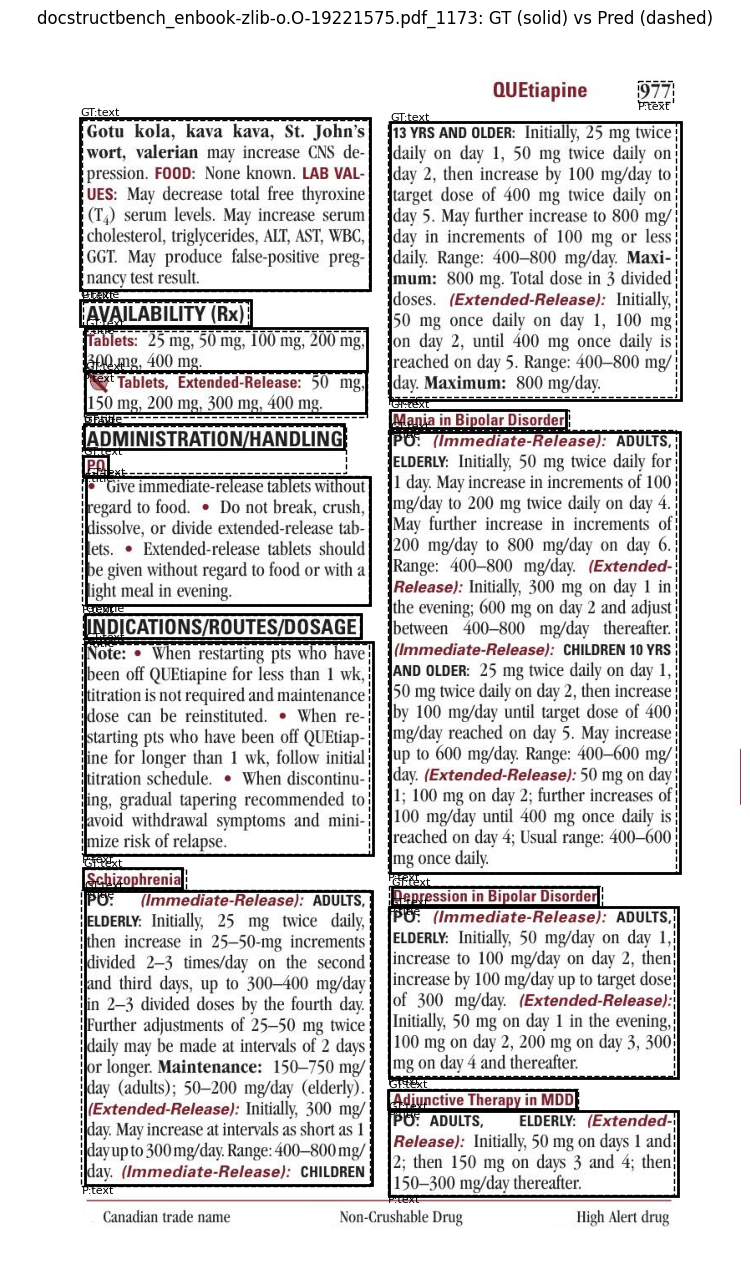

In [42]:
def draw_boxes_for_sample(sample_id, gt_df, pred_df, manifest_df, show_labels=True, figsize=(12, 16)):
    row = manifest_df[manifest_df["sample_id"].astype(str) == str(sample_id)]
    if row.empty:
        raise ValueError(f"sample_id not found in manifest: {sample_id}")
    row = row.iloc[0]
    img_path = row.get("input_image_path")
    if not img_path or not Path(img_path).exists():
        raise FileNotFoundError("No image available for this sample. Dataset prep should export images.")
    img = Image.open(img_path).convert("RGB")
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img)
    ax.set_title(f"{sample_id}: GT (solid) vs Pred (dashed)")
    g = gt_df[gt_df["sample_id"].astype(str) == str(sample_id)]
    p = pred_df[pred_df["sample_id"].astype(str) == str(sample_id)]
    for _, r in g.iterrows():
        b = r["bbox"]
        rect = plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], fill=False, linewidth=2)
        ax.add_patch(rect)
        if show_labels:
            ax.text(b[0], b[1], f"GT:{r['eval_label']}", fontsize=8, va="bottom")
    for _, r in p.iterrows():
        b = r["bbox"]
        if b is None:
            continue
        rect = plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], fill=False, linewidth=1, linestyle="--")
        ax.add_patch(rect)
        if show_labels:
            ax.text(b[0], b[3], f"P:{r['eval_label']}", fontsize=8, va="top")
    ax.axis("off")
    plt.show()

if "manifest_df" in globals() and len(manifest_df) and len(pred_df):
    sample_ids = sorted(set(gt_df["sample_id"].astype(str)) & set(pred_df["sample_id"].astype(str)))
    print("Available samples with predictions:", sample_ids[:10])
    # Uncomment one:
    draw_boxes_for_sample(sample_ids[0], gt_df, pred_df, manifest_df)
else:
    print("Need manifest + predictions for visual diagnostics.")

## 15. Summary report

In [40]:
summary = {}
if len(layout_summary_df):
    row50 = layout_summary_df[layout_summary_df["iou_threshold"] == 0.5]
    if len(row50):
        summary.update({
            "layout_precision_at_0_5": float(row50.iloc[0]["precision"]),
            "layout_recall_at_0_5": float(row50.iloc[0]["recall"]),
            "layout_f1_at_0_5": float(row50.iloc[0]["f1"]),
            "layout_mean_iou": float(row50.iloc[0]["mean_iou_at_first_threshold"]) if not pd.isna(row50.iloc[0]["mean_iou_at_first_threshold"]) else np.nan,
        })
    row75 = layout_summary_df[layout_summary_df["iou_threshold"] == 0.75]
    if len(row75):
        summary["layout_f1_at_0_75"] = float(row75.iloc[0]["f1"])

summary.update(text_summary)
summary.update(formula_summary)
summary.update(table_summary)
summary.update(reading_order_summary)
summary.update(json_summary)

# Add runtime if recognizable total/page fields exist
if "runtime_df" in globals() and len(runtime_df):
    summary["timing_files_count"] = int(len(runtime_df))
    for col in runtime_df.columns:
        low = col.lower()
        if "seconds_per_page" in low or low.endswith("sec_per_page"):
            summary["runtime_seconds_per_page_mean"] = float(pd.to_numeric(runtime_df[col], errors="coerce").mean())
        if low in {"total_time", "total_seconds", "elapsed_seconds", "duration_seconds"}:
            summary[f"runtime_{col}_mean"] = float(pd.to_numeric(runtime_df[col], errors="coerce").mean())

summary_path = OUTPUT_DIR / "summary_metrics.json"
summary_csv_path = OUTPUT_DIR / "summary_metrics.csv"
pd.DataFrame([summary]).to_csv(summary_csv_path, index=False)
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2, default=str), encoding="utf-8")

# Save detailed tables
for name, df in {
    "layout_summary.csv": layout_summary_df,
    "per_class_layout_metrics.csv": per_class_layout_df,
    "matched_elements.csv": matches_df,
    "false_positives.csv": false_positives_df,
    "false_negatives.csv": false_negatives_df,
    "text_metrics.csv": text_metrics_df,
    "formula_metrics.csv": formula_metrics_df,
    "table_metrics.csv": table_metrics_df,
    "reading_order_metrics.csv": reading_order_df,
}.items():
    if df is not None and len(df):
        df.to_csv(OUTPUT_DIR / name, index=False)

print("Summary:")
display(pd.DataFrame([summary]))
print("Saved:", summary_path)
print("Saved:", summary_csv_path)

Summary:


,layout_precision_at_0_5,layout_recall_at_0_5,layout_f1_at_0_5,layout_mean_iou,layout_f1_at_0_75,text_norm_edit_distance_mean,text_similarity_mean,text_exact_match_rate,text_bleu_mean,text_meteor_mean,...,reading_order_similarity_mean,pairwise_order_accuracy_mean,prediction_blocks,prediction_samples,empty_text_rate_non_visual,invalid_bbox_count,missing_bbox_count,missing_reading_order_count,timing_files_count,runtime_elapsed_seconds_mean
0,0.706215,0.739645,0.722543,0.893549,0.653179,0.136065,0.863935,0.26087,0.606597,0.903759,...,0.995652,0.999415,177,10,0.041916,0,0,0,36,110.11


Saved: c:\Users\David Martirosyan\Documents\Projects\Agentic PDF Parser\evaluation_results_omni\omnidocbench_v15_english\summary_metrics.json
Saved: c:\Users\David Martirosyan\Documents\Projects\Agentic PDF Parser\evaluation_results_omni\omnidocbench_v15_english\summary_metrics.csv
